In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

useful_image = np.load(PROCESSED_DATA / "useful_image.npy")

print("Useful image loaded")
print("Shape:", useful_image.shape)

print("Useful image loaded")
print("Shape:", useful_image.shape)

Useful image loaded
Shape: (16444, 12000)


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "Data1"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
MODELS = PROJECT_ROOT / "models"

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("Processed data:", PROCESSED_DATA)

In [ ]:
crop_size = 1000

useful_crops = []
crop_locations = []

for y in range(0, useful_image.shape[0], crop_size):
    for x in range(0, useful_image.shape[1], crop_size):
        crop = useful_image[y:y+crop_size, x:x+crop_size]

        if crop.shape == (crop_size, crop_size):
            useful_crops.append(crop)
            crop_locations.append((y, x))

print("Total crops:", len(useful_crops))

Total crops: 192


In [ ]:
os.makedirs("data/processed", exist_ok=True)

np.save("data/processed/useful_crops.npy", np.array(useful_crops))
np.save("data/processed/crop_locations.npy", np.array(crop_locations))

print("Saved useful_crops and crop_locations")

Saved useful_crops and crop_locations


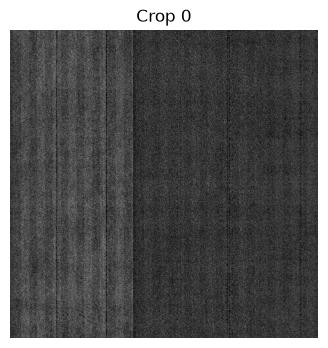

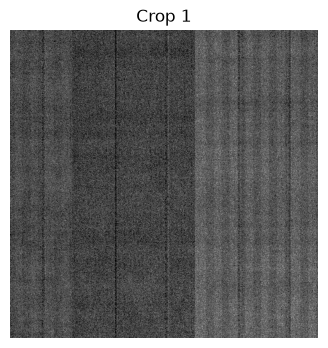

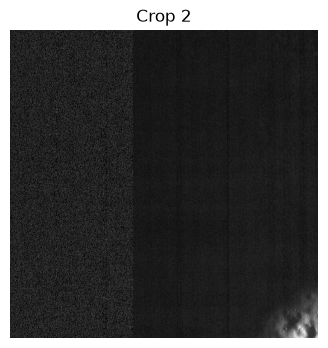

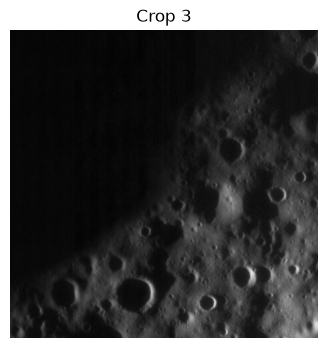

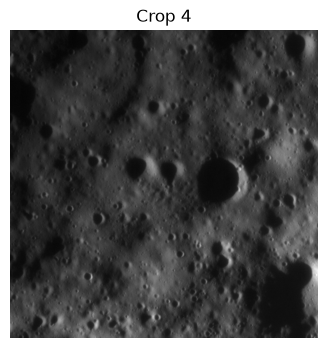

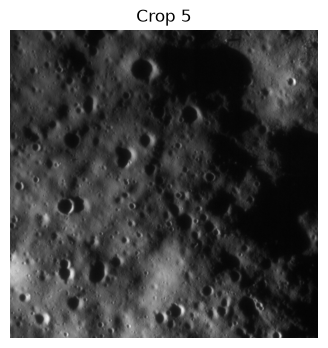

In [ ]:
for i in range(6):
    plt.figure(figsize=(4,4))
    plt.imshow(useful_crops[i], cmap="gray")
    plt.title(f"Crop {i}")
    plt.axis("off")
    plt.show()

In [ ]:
filtered_crops = []
filtered_locations = []

for crop, loc in zip(useful_crops, crop_locations):
    mean_brightness = crop.mean()
    std_brightness = crop.std()
    shadow_percentage = (crop < 20).sum() / crop.size * 100

    # Keep crops that have actual visible terrain/variation
    if std_brightness > 5 and shadow_percentage < 95:
        filtered_crops.append(crop)
        filtered_locations.append(loc)

print("Original crops:", len(useful_crops))
print("Filtered useful crops:", len(filtered_crops))

Original crops: 192
Filtered useful crops: 89


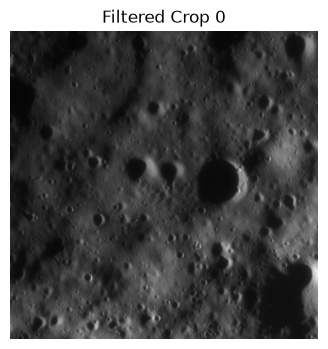

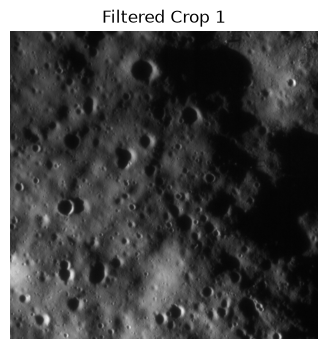

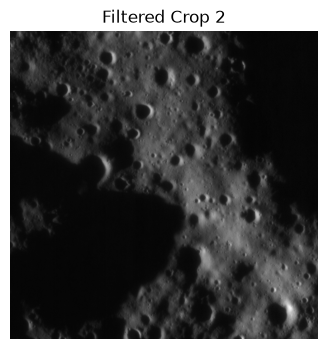

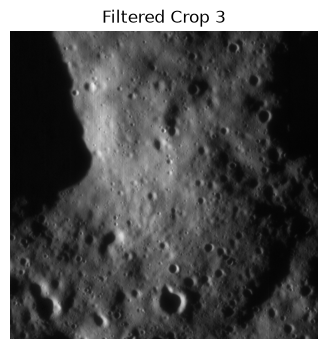

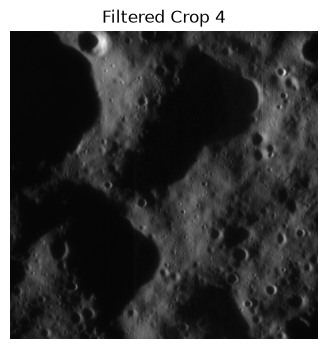

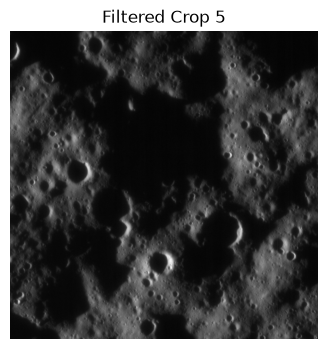

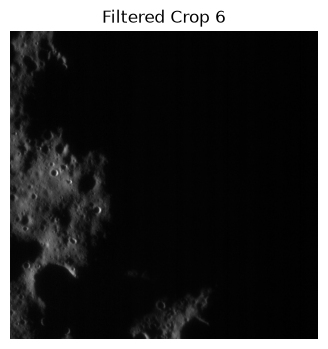

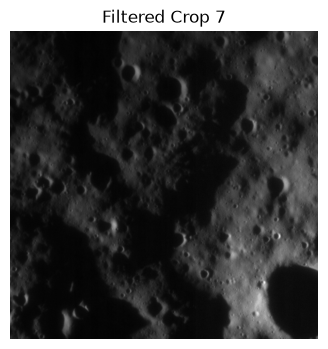

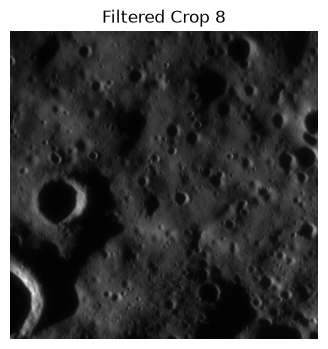

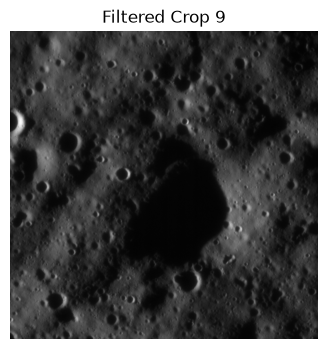

In [ ]:
for i in range(min(10, len(filtered_crops))):
    plt.figure(figsize=(4,4))
    plt.imshow(filtered_crops[i], cmap="gray")
    plt.title(f"Filtered Crop {i}")
    plt.axis("off")
    plt.show()

In [ ]:
np.save(PROCESSED_DATA / "useful_crops.npy", np.array(useful_crops))
np.save(PROCESSED_DATA / "crop_locations.npy", np.array(crop_locations))
np.save(PROCESSED_DATA / "filtered_crops.npy", np.array(filtered_crops))
np.save(PROCESSED_DATA / "filtered_locations.npy", np.array(filtered_locations))

print("Saved preprocessing outputs")

Saved filtered crops and locations


In [ ]:
crop_size = 1000

useful_crops = []
crop_locations = []

for y in range(0, useful_image.shape[0], crop_size):
    for x in range(0, useful_image.shape[1], crop_size):

        crop = useful_image[y:y+crop_size, x:x+crop_size]

        if crop.shape == (crop_size, crop_size):
            useful_crops.append(crop)
            crop_locations.append((y, x))

print("Original crops:", len(useful_crops))

Original crops: 192


In [ ]:
import os

print(os.listdir("data/processed"))

['useful_image.npy', 'filtered_crops.npy', 'useful_crops.npy', 'filtered_locations.npy', 'crop_locations.npy']
